
===== LAZO ABIERTO =====

tao = 0.47 s
C1 = 47.0 µF
R = 10000 Ω
Yf = 1.000
T10 ≈ 0.080 s
T95 ≈ 1.441 s

tao = 4.70 s
C1 = 47.0 µF
R = 100000 Ω
Yf = 1.000
T10 ≈ 0.521 s
T95 ≈ 14.094 s

tao = 8.46 s
C1 = 47.0 µF
R = 180000 Ω
Yf = 0.991
T10 ≈ 0.921 s
T95 ≈ 24.064 s

===== RESULTADOS =====
τ (s)   Yf      T10 (s)   y(T10)    T95 (s)   y(T95)    Ts (s)    
0.47    1.00    0.08      0.16      1.44      0.95      1.36      
4.70    1.00    0.52      0.10      14.09     0.95      13.57     
8.46    0.99    0.92      0.10      24.06     0.94      23.14     


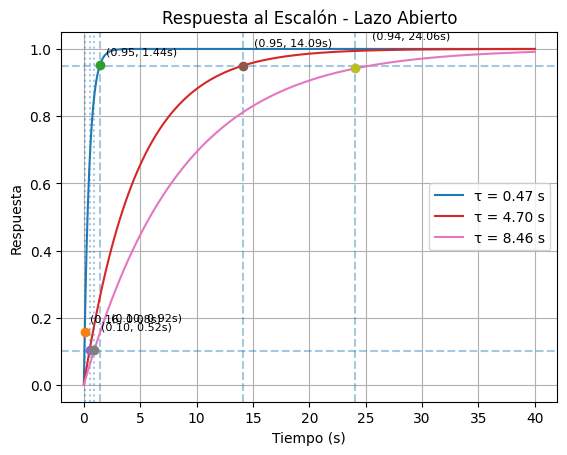

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# =========================
# FUNCION PARA Ts y Yf
# =========================
def calcular_metricas(t, y):
    Yf = y[-1]
    
    y_95 = 0.95 * Yf
    y_10 = 0.10 * Yf
    
    # Índice 95%
    idx_95 = np.where(y >= y_95)[0]
    idx_95 = idx_95[0] if len(idx_95) > 0 else None
    T95 = t[idx_95] if idx_95 is not None else None

    # Índice 10%
    idx_10 = np.where(y >= y_10)[0]
    idx_10 = idx_10[0] if len(idx_10) > 0 else None
    T10 = t[idx_10] if idx_10 is not None else None

    return Yf, T95, idx_95, T10, idx_10

# =========================
# PARTE 1: LAZO ABIERTO
# =========================
C1 = 47 * 1e-6 #|µF
R1 = 10000 # Ω
tao1 = R1 * C1  # 0.47 s

R2 = 100000 # Ω
tao2 = R2 * C1  # 4.7 s 

R3 = 180000 # Ω
tao3 = R3 * C1  # 9.4 s

taos = [tao1, tao2, tao3]
t = np.linspace(0, 40, 1000)

plt.figure()
print("\n===== LAZO ABIERTO =====")

for i, tao in enumerate(taos):
    
    sistema = ctrl.TransferFunction([1], [tao, 1])
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, T95, idx_95, T10, idx_10 = calcular_metricas(t_out, y)

    print(f"\ntao = {tao:.2f} s")
    print(f"C1 = {C1 * 1e6:.1f} µF")
    print(f"R = {tao / C1:.0f} Ω")
    print(f"Yf = {Yf:.3f}")
    print(f"T10 ≈ {T10:.3f} s")
    print(f"T95 ≈ {T95:.3f} s")

    plt.plot(t_out, y, label=f'τ = {tao:.2f} s')

    if i == 0:
        plt.axhline(0.10 * Yf, linestyle='--', alpha=0.4)
        plt.axhline(0.95 * Yf, linestyle='--', alpha=0.4)

    plt.axvline(T10, linestyle=':', alpha=0.4)
    plt.axvline(T95, linestyle='--', alpha=0.4)

    plt.plot(t_out[idx_10], y[idx_10], 'o')
    plt.plot(t_out[idx_95], y[idx_95], 'o')

    # 🔹 Offsets dinámicos en X y Y
    offset_y = (i + 1) * 0.03 * Yf
    offset_x = (i + 1) * 0.5   # mueve en tiempo

    # Etiquetas separadas
    plt.text(
        t_out[idx_10] + offset_x, 
        y[idx_10] + offset_y, 
        f'({y[idx_10]:.2f}, {T10:.2f}s)', 
        fontsize=8
    )

    plt.text(
        t_out[idx_95] + offset_x, 
        y[idx_95] + offset_y, 
        f'({y[idx_95]:.2f}, {T95:.2f}s)', 
        fontsize=8
    )

plt.grid()
plt.xlabel('Tiempo (s)')
plt.ylabel('Respuesta')
plt.title('Respuesta al Escalón - Lazo Abierto')
plt.legend()

print("\n===== RESULTADOS =====")
print(f"{'τ (s)':<8}{'Yf':<8}{'T10 (s)':<10}{'y(T10)':<10}{'T95 (s)':<10}{'y(T95)':<10}{'Ts (s)':<10}")

for tao in taos:
    sistema = ctrl.TransferFunction([1], [tao, 1])
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, T95, idx_95, T10, idx_10 = calcular_metricas(t_out, y)

    Ts = T95 - T10 if (T95 is not None and T10 is not None) else None
    
    y_T10 = y[idx_10] if idx_10 is not None else None
    y_T95 = y[idx_95] if idx_95 is not None else None

    print(f"{tao:<8.2f}{Yf:<8.2f}{T10:<10.2f}{y_T10:<10.2f}{T95:<10.2f}{y_T95:<10.2f}{Ts:<10.2f}")


===== LAZO ABIERTO =====


<Figure size 640x480 with 0 Axes>

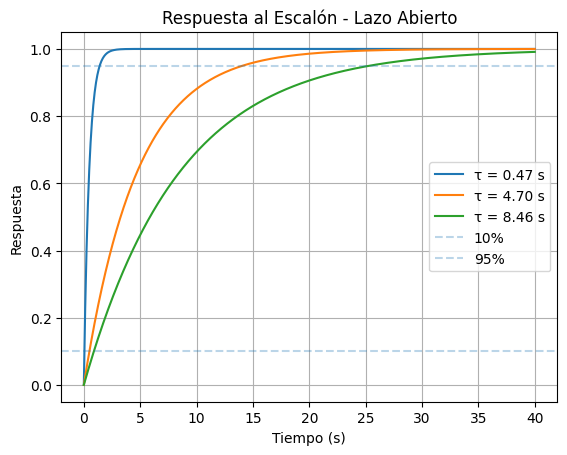

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

def calcular_metricas(t, y):
    Yf = y[-1]
    
    y_95 = 0.95 * Yf
    y_10 = 0.10 * Yf
    
    idx_95 = np.where(y >= y_95)[0]
    idx_95 = idx_95[0] if len(idx_95) > 0 else None
    T95 = t[idx_95] if idx_95 is not None else None

    idx_10 = np.where(y >= y_10)[0]
    idx_10 = idx_10[0] if len(idx_10) > 0 else None
    T10 = t[idx_10] if idx_10 is not None else None

    return Yf, T95, idx_95, T10, idx_10


# Parámetros
C1 = 47e-6
R1, R2, R3 = 10000, 100000, 180000

taos = [R1*C1, R2*C1, R3*C1]
t = np.linspace(0, 40, 1000)

plt.figure()
print("\n===== LAZO ABIERTO =====")

# offsets predefinidos (clave para NO superponer)
offsets = [
    (1.5, 0.02),
    (2.5, 0.04),
    (3.5, 0.06)
]

plt.figure()

for i, tao in enumerate(taos):
    sistema = ctrl.TransferFunction([1], [tao, 1])
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, T95, idx_95, T10, idx_10 = calcular_metricas(t_out, y)

    plt.plot(t_out, y, label=f'τ = {tao:.2f} s')

# líneas de referencia (una sola vez)
plt.axhline(0.10, linestyle='--', alpha=0.3, label='10%')
plt.axhline(0.95, linestyle='--', alpha=0.3, label='95%')

plt.grid()
plt.xlabel('Tiempo (s)')
plt.ylabel('Respuesta')
plt.title('Respuesta al Escalón - Lazo Abierto')
plt.legend()
plt.show()




===== LAZO CERRADO =====

K = 0.5
Yf = 0.333
T10 ≈ 0.240 s
T95 ≈ 6.006 s

K = 2
Yf = 0.667
T10 ≈ 0.120 s
T95 ≈ 3.003 s

K = 5
Yf = 0.833
T10 ≈ 0.080 s
T95 ≈ 1.522 s

K = 10
Yf = 0.909
T10 ≈ 0.040 s
T95 ≈ 0.841 s


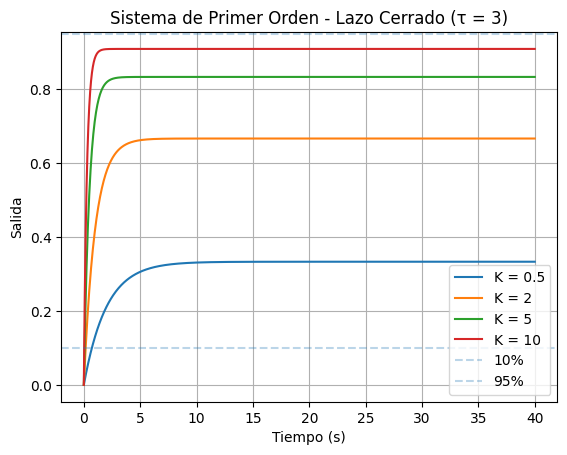

In [10]:
# =========================
# PARTE 2: LAZO CERRADO
# =========================
K_values = [0.5, 2, 5, 10]
tau = 3

t = np.linspace(0, 40, 1000)

plt.figure()
print("\n===== LAZO CERRADO =====")

for K in K_values:
    
    G = ctrl.TransferFunction([1], [tau, 1])
    
    # Lazo cerrado
    sistema_cerrado = ctrl.feedback(K * G, 1)
    
    t_out, y = ctrl.step_response(sistema_cerrado, t)
    
    Yf, T95, _, T10, _ = calcular_metricas(t_out, y)
    
    print(f"\nK = {K}")
    print(f"Yf = {Yf:.3f}")
    print(f"T10 ≈ {T10:.3f} s")
    print(f"T95 ≈ {T95:.3f} s")
    
    plt.plot(t_out, y, label=f'K = {K}')

# Líneas de referencia (una sola vez)
plt.axhline(0.10, linestyle='--', alpha=0.3, label='10%')
plt.axhline(0.95, linestyle='--', alpha=0.3, label='95%')

plt.title("Sistema de Primer Orden - Lazo Cerrado (τ = 3)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.grid()
plt.legend()
plt.show()

## Esta es la parte de segundo orden 
yo la comence pero hay que mejorarla y colocarle los valores de R para variar de valor comercial y C intentar dejarla fija en valor comercial
Recordar que L es fija en 470 uH


===== CASO 1: MISMO ζ, DIFERENTE ωn =====

Caso 1A
R=10.00 Ω, C=0.000010 F
wn=14586.50, zeta=0.729
Yf=1.000, Mp=3.50%, Ts=0.000200s

Caso 1B
R=14.59 Ω, C=0.000005 F
wn=21276.60, zeta=0.729
Yf=1.000, Mp=3.50%, Ts=0.000140s

===== CASO 2: MISMO ωn, DIFERENTE ζ =====

Subamortiguado
R=5 Ω
wn=14586.50, zeta=0.365
Yf=1.000, Mp=28.98%, Ts=0.000521s

Sobreamortiguado
R=100 Ω
wn=14586.50, zeta=7.293
Yf=1.000, Mp=0.00%, Ts=0.002983s


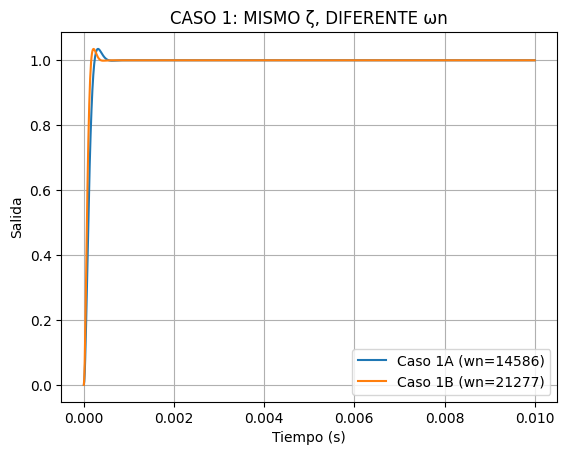

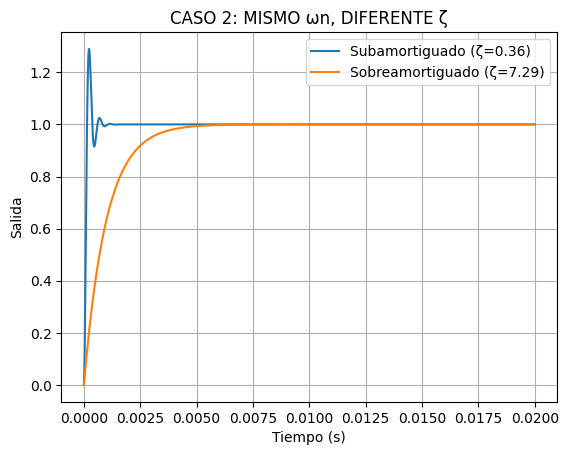

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# =========================
# PARÁMETROS FIJOS
# =========================
L = 470e-6  # 470 uH

# Función para calcular métricas
def calcular_metricas(t, y):
    Yf = y[-1]
    Mp = (np.max(y) - Yf) / Yf * 100
    
    tolerance = 0.05 * Yf
    indices = np.where(np.abs(y - Yf) > tolerance)[0]
    
    if len(indices) > 0:
        Ts = t[indices[-1]]
    else:
        Ts = 0
        
    return Yf, Mp, Ts

# =========================
# CASO 1: MISMO ζ, DIFERENTE ωn
# =========================
print("\n===== CASO 1: MISMO ζ, DIFERENTE ωn =====")

# Ajustamos R proporcionalmente para mantener ζ similar
C1 = 10e-6   # 10 uF
R1 = 10      # ohm

C2 = 4.7e-6  # 4.7 uF (valor comercial)
R2 = R1 * np.sqrt(C1/C2)  # ajustar R para mantener ζ

caso1 = [(R1, C1, "Caso 1A"), (R2, C2, "Caso 1B")]

plt.figure()

for R, C, label in caso1:
    
    num = [1]
    den = [L*C, R*C, 1]
    sistema = ctrl.TransferFunction(num, den)
    
    wn = np.sqrt(1/(L*C))
    zeta = (R/2)*np.sqrt(C/L)
    
    t = np.linspace(0, 0.01, 1000)
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, Mp, Ts = calcular_metricas(t_out, y)
    
    print(f"\n{label}")
    print(f"R={R:.2f} Ω, C={C:.6f} F")
    print(f"wn={wn:.2f}, zeta={zeta:.3f}")
    print(f"Yf={Yf:.3f}, Mp={Mp:.2f}%, Ts={Ts:.6f}s")
    
    plt.plot(t_out, y, label=f"{label} (wn={wn:.0f})")

plt.title("CASO 1: MISMO ζ, DIFERENTE ωn")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.legend()
plt.grid()


# =========================
# CASO 2: MISMO ωn, DIFERENTE ζ
# =========================
print("\n===== CASO 2: MISMO ωn, DIFERENTE ζ =====")

# Mantener L y C constantes
C = 10e-6  # 10 uF

# Resistencias reales (valores comerciales)
R_sub = 5     # subamortiguado
R_sobre = 100 # sobreamortiguado

caso2 = [(R_sub, "Subamortiguado"), (R_sobre, "Sobreamortiguado")]

plt.figure()

for R, label in caso2:
    
    num = [1]
    den = [L*C, R*C, 1]
    sistema = ctrl.TransferFunction(num, den)
    
    wn = np.sqrt(1/(L*C))
    zeta = (R/2)*np.sqrt(C/L)
    
    t = np.linspace(0, 0.02, 1000)
    t_out, y = ctrl.step_response(sistema, t)
    
    Yf, Mp, Ts = calcular_metricas(t_out, y)
    
    print(f"\n{label}")
    print(f"R={R} Ω")
    print(f"wn={wn:.2f}, zeta={zeta:.3f}")
    print(f"Yf={Yf:.3f}, Mp={Mp:.2f}%, Ts={Ts:.6f}s")
    
    plt.plot(t_out, y, label=f"{label} (ζ={zeta:.2f})")

plt.title("CASO 2: MISMO ωn, DIFERENTE ζ")
plt.xlabel("Tiempo (s)")
plt.ylabel("Salida")
plt.legend()
plt.grid()

plt.show()